## SOVRENINS STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

sovrenins=pd.read_csv('../stock_data/sovrenins.csv') ## so it can be small letter. This is cool.
sovrenins=sovrenins.drop(columns=['high_price','low_price'])
sovrenins.rename(columns={'trade_date':'date'},inplace=True)
sovrenins['date']=pd.to_datetime(sovrenins['date'])
sovrenins['month']=sovrenins['date'].dt.month
sovrenins['quarter']=sovrenins['date'].dt.quarter
sovrenins['year']=sovrenins['date'].dt.year

sovrenins

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42818,SOVRENINS,2017-01-03,0.50,0.50,2000,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43378,SOVRENINS,2017-01-04,0.50,0.50,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43488,SOVRENINS,2017-01-05,0.50,0.50,92000,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43598,SOVRENINS,2017-01-06,0.50,0.50,0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43688,SOVRENINS,2017-01-09,0.50,0.50,1000,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298130,SOVRENINS,2026-07-13,1.86,1.86,1367730,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298568,SOVRENINS,2026-07-14,2.00,2.00,2741658,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299006,SOVRENINS,2026-07-15,2.00,2.00,1331839,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299444,SOVRENINS,2026-07-16,2.00,2.00,773567,2026-07-16T15:10:03.113936+00:00,7,3,2026


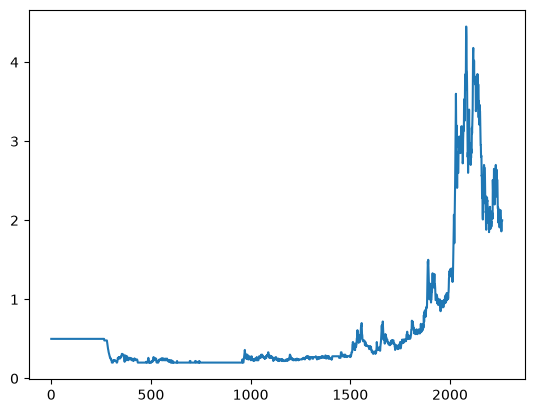

In [2]:
import matplotlib.pyplot as plt

plt.plot(sovrenins['close_price'])
plt.show()

In [3]:
sovrenins_end_month_df = (
    sovrenins
    .sort_values("date")
    .groupby(sovrenins["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

sovrenins_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45388,SOVRENINS,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47210,SOVRENINS,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49326,SOVRENINS,2017-03-31,0.50,0.50,500,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51154,SOVRENINS,2017-04-28,0.50,0.50,1000,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53076,SOVRENINS,2017-05-31,0.50,0.50,0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35367,SOVRENINS,2026-03-31,2.17,2.17,2910155,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281193,SOVRENINS,2026-04-30,2.08,2.08,20115029,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284259,SOVRENINS,2026-05-29,2.48,2.48,3932702,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294187,SOVRENINS,2026-06-30,1.91,1.91,4339960,2026-06-30T15:10:03.08168+00:00,6,2,2026


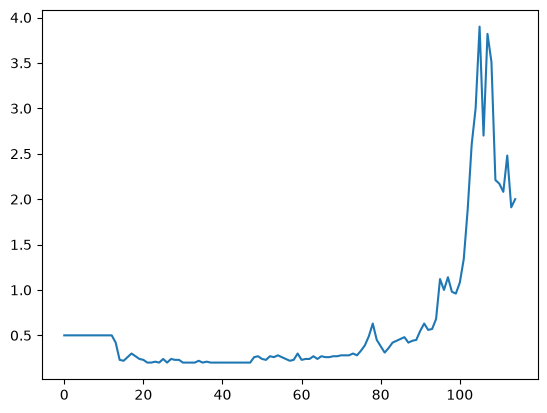

In [4]:
plt.plot(sovrenins_end_month_df['close_price'])
plt.show()

In [5]:
sovrenins_end_month_df['returns']=sovrenins_end_month_df['close_price'].pct_change()*100
sovrenins_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45388,SOVRENINS,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47210,SOVRENINS,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49326,SOVRENINS,2017-03-31,0.50,0.50,500,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51154,SOVRENINS,2017-04-28,0.50,0.50,1000,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53076,SOVRENINS,2017-05-31,0.50,0.50,0,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35367,SOVRENINS,2026-03-31,2.17,2.17,2910155,2026-03-31T15:00:02.085058+00:00,3,1,2026,-1.809955
111,281193,SOVRENINS,2026-04-30,2.08,2.08,20115029,2026-04-30T15:00:02.170664+00:00,4,2,2026,-4.147465
112,284259,SOVRENINS,2026-05-29,2.48,2.48,3932702,2026-05-29T15:00:02.455558+00:00,5,2,2026,19.230769
113,294187,SOVRENINS,2026-06-30,1.91,1.91,4339960,2026-06-30T15:10:03.08168+00:00,6,2,2026,-22.983871


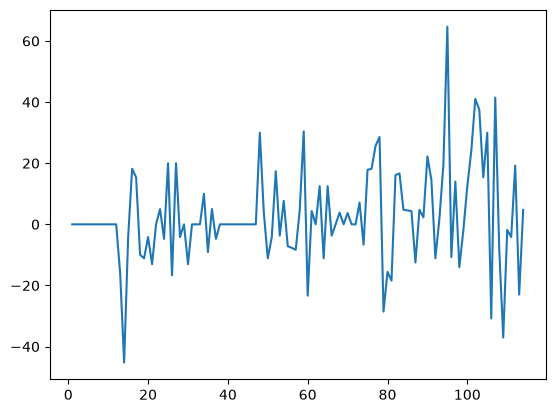

In [6]:
plt.plot(sovrenins_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(sovrenins_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-10.078333969819298), np.float64(1.2070616403782993e-17), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(841.1831630630398))
stationary


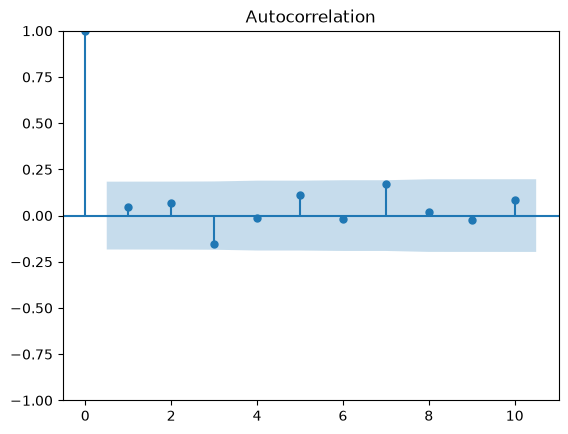

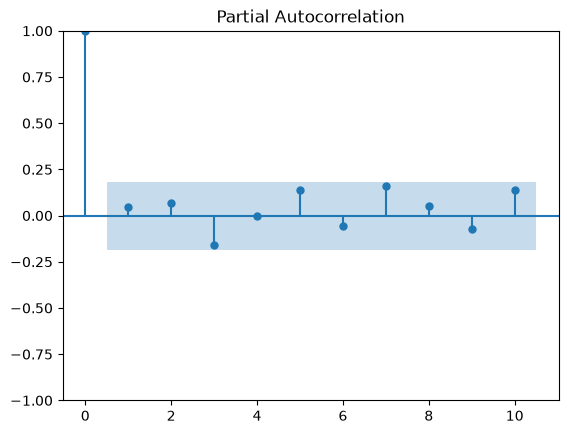

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(sovrenins_end_month_df['returns'].dropna(), lags=10)
plot_pacf(sovrenins_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=sovrenins_end_month_df['close_price'][:-10]
test=sovrenins_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -13.247630025343767]
[0, 0, 0, 0, 0, 1, -8.470622437630903]
[0, 0, 0, 0, 0, 2, -7.350059600654593]
[0, 0, 0, 0, 1, 0, -5.441565254656824]
[0, 0, 0, 0, 1, 1, -4.8710241323677606]
[0, 0, 0, 0, 1, 2, -4.400792304966913]
[0, 0, 0, 0, 2, 0, -3.299370469565093]
[0, 0, 0, 0, 2, 1, -3.4555903291341385]
[0, 0, 0, 0, 2, 2, -3.284095540550288]
[0, 0, 0, 1, 0, 0, -6.089404869623289]
[0, 0, 0, 1, 0, 1, -5.796682148897807]
[0, 0, 0, 1, 0, 2, -5.461365812725698]
[0, 0, 0, 1, 1, 0, -4.320056131145229]
[0, 0, 0, 1, 1, 1, -4.395522971109312]
[0, 0, 0, 1, 1, 2, -4.356249471829609]
[0, 0, 0, 1, 2, 0, -3.617798016435292]
[0, 0, 0, 1, 2, 1, -3.477517108131315]
[0, 0, 0, 1, 2, 2, -3.3191639473514574]
[0, 0, 0, 2, 0, 0, -5.6308655615533665]
[0, 0, 0, 2, 0, 1, -6.166592115835691]
[0, 0, 0, 2, 0, 2, -5.547413743156245]
[0, 0, 0, 2, 1, 0, -4.552080695379579]
[0, 0, 0, 2, 1, 1, -4.41807091981679]
[0, 0, 0, 2, 1, 2, -4.3927979122067]
[0, 0, 0, 2, 2, 0, -3.331294061789439]
[0, 0, 0, 2, 2, 1, -3.5

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
447,1,2,1,1,2,0,-41.527136
663,2,2,0,1,2,0,-41.102491
420,1,2,0,1,2,0,-40.739550
656,2,2,0,0,2,2,-39.917883
683,2,2,1,0,2,2,-39.530521
...,...,...,...,...,...,...,...
108,0,1,1,0,0,0,-0.291965
533,2,0,1,2,0,2,-0.236183
81,0,1,0,0,0,0,-0.191526
270,1,0,1,0,0,0,-0.175495


Its not capturing the variations properly. Lets try the returns

In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=sovrenins_end_month_df['returns'].dropna()[:-10]
test=sovrenins_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.0015005167092372318]
[0, 0, 0, 0, 0, 1, 0.05616607461119516]
[0, 0, 0, 0, 0, 2, 0.04352025198232623]
[0, 0, 0, 0, 1, 0, -0.7159461305624313]
[0, 0, 0, 0, 1, 1, -0.19603003969104416]
[0, 0, 0, 0, 1, 2, -0.30865359812631055]
[0, 0, 0, 0, 2, 0, -2.5106125099286016]
[0, 0, 0, 0, 2, 1, -1.00125607887475]
[0, 0, 0, 0, 2, 2, -0.7120682405164487]
[0, 0, 0, 1, 0, 0, 0.05438798431482872]
[0, 0, 0, 1, 0, 1, -0.00991632881255522]
[0, 0, 0, 1, 0, 2, -0.0733304257086349]
[0, 0, 0, 1, 1, 0, -0.3788646120298764]
[0, 0, 0, 1, 1, 1, -0.22174713261016654]
[0, 0, 0, 1, 1, 2, -0.3347512983374272]
[0, 0, 0, 1, 2, 0, -1.2947029066781135]
[0, 0, 0, 1, 2, 1, -0.6574160829385034]
[0, 0, 0, 1, 2, 2, -0.7071903977660163]
[0, 0, 0, 2, 0, 0, 0.021050387720759955]
[0, 0, 0, 2, 0, 1, -0.033302924330315786]
[0, 0, 0, 2, 0, 2, -0.03929429645580118]
[0, 0, 0, 2, 1, 0, -0.34765423592190725]
[0, 0, 0, 2, 1, 1, -0.3533657407398778]
[0, 0, 0, 2, 1, 2, -0.4258680679480471]
[0, 0, 0, 2, 2, 0, -1.02049228

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-160.810323
420,1,2,0,1,2,0,-45.418874
167,0,2,0,0,1,2,-44.522394
177,0,2,0,1,2,0,-43.711701
663,2,2,0,1,2,0,-30.215102
...,...,...,...,...,...,...,...
550,2,0,2,1,0,1,0.103721
558,2,0,2,2,0,0,0.135183
542,2,0,2,0,0,2,0.137980
541,2,0,2,0,0,1,0.139007


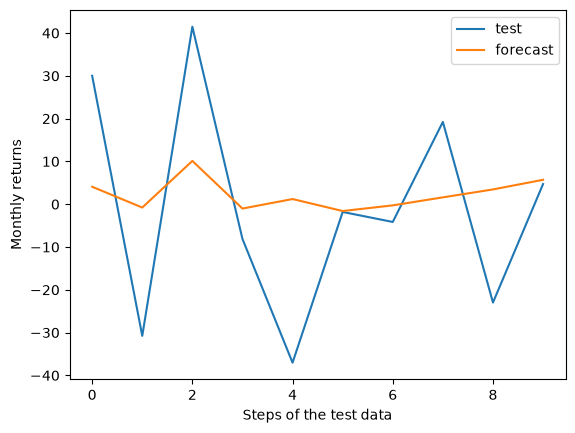

r2_score:  0.14201788344713184
rmse:  22.56936610923678
description:  count    114.000000
mean       2.426577
std       15.766195
min      -45.238095
25%       -4.302536
50%        0.000000
75%        9.423077
max       64.705882
Name: returns, dtype: float64


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=sovrenins_end_month_df['returns'].dropna()[:-10]
y_test=sovrenins_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,0,2), 
seasonal_order=(1,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', sovrenins_end_month_df.returns.dropna().describe())

Very horrible. We will work with it.
